In [17]:
# Install the required packages
%pip install -q langgraph langchain-groq python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

# Automatically load environment variables from the local .env file
load_dotenv()

# Verify the key is loaded
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY not found. Make sure it is defined in your .env file.")

# Initialize the LLM (Using the reliable production model)
model = ChatGroq(model="openai/gpt-oss-20b", temperature=0)

In [19]:
from typing import TypedDict, List, Dict, Any, Optional

class EmailState(TypedDict):
    email: Dict[str, Any]
    is_spam: Optional[bool]
    triage_dossier: Optional[str]  # Sentinel's briefing handed off to Scribe
    email_draft: Optional[str]
    saved_filepath: Optional[str]  # Local file path where Scribe saves the draft
    messages: List[Dict[str, Any]]

In [20]:
from langchain_core.messages import HumanMessage
import os
import re
from datetime import datetime

# --- AGENT 1: SENTINEL (Triage & Intelligence Analyst) ---
def sentinel_triage_agent(state: EmailState):
    email = state["email"]
    print(f"\n[Sentinel] Scanning incoming email from: {email['sender']}")

    prompt = f"""
You are "Sentinel", an AI Security and Triage Agent protecting Waryam's inbox.
Analyze this email and provide your intelligence assessment.

Email:
From: {email['sender']}
Subject: {email['subject']}
Body: {email['body']}

Perform two tasks:
1. Determine if this email is SPAM or HAM (legitimate).
2. If HAM, write a concise 2-sentence Strategic Briefing for the drafting agent (Scribe), identifying the sender's intent, priority level, and key points to address.

Format your output EXACTLY like this:
VERDICT: [SPAM or HAM]
BRIEFING: [Your strategic briefing, or 'N/A' if spam]
"""
    response = model.invoke([HumanMessage(content=prompt)]).content.strip()
    
    # Simple parsing logic
    is_spam = "VERDICT: SPAM" in response.upper() or ("SPAM" in response.split("\n")[0].upper() and "HAM" not in response.split("\n")[0].upper())
    
    dossier = "No briefing (marked as spam)."
    if not is_spam and "BRIEFING:" in response:
        dossier = response.split("BRIEFING:")[1].strip()

    print(f"[Sentinel] Verdict: {'SPAM' if is_spam else 'HAM'}")
    if not is_spam:
        print(f"[Sentinel] Handing off dossier to Scribe:\n  -> \"{dossier}\"")

    return {"is_spam": is_spam, "triage_dossier": dossier}

# --- QUARANTINE ROUTE ---
def quarantine_spam(state: EmailState):
    print("[Quarantine] Spam detected. Diverting to junk folder. Scribe execution halted.")
    return {}

# --- AGENT 2: SCRIBE (Communications & Archival Agent) ---
def scribe_drafting_agent(state: EmailState):
    email = state["email"]
    dossier = state.get("triage_dossier", "Standard professional correspondence.")
    
    print("\n[Scribe] Receiving dossier from Sentinel. Crafting response...")

    prompt = f"""
You are "Scribe", the Executive Communications Agent for Waryam.
Sentinel (Triage Agent) has provided the following strategic briefing on an incoming email:
"{dossier}"

Original Email:
From: {email['sender']}
Subject: {email['subject']}
Body: {email['body']}

Draft a concise, professional reply acknowledging the email in accordance with Sentinel's briefing.
Sign off as Waryam. Output ONLY the email response text.
"""
    draft = model.invoke([HumanMessage(content=prompt)]).content.strip()

    # Tool Execution: Save draft to local disk
    os.makedirs("saved_drafts", exist_ok=True)
    clean_subject = re.sub(r'[^\w\-]', '_', email['subject'])[:30]
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"saved_drafts/draft_{clean_subject}_{timestamp}.txt"

    with open(filename, "w", encoding="utf-8") as f:
        f.write(f"TO: {email['sender']}\n")
        f.write(f"SUBJECT: Re: {email['subject']}\n")
        f.write(f"TIMESTAMP: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"SENTINEL BRIEFING: {dossier}\n")
        f.write("=" * 50 + "\n\n")
        f.write(draft)

    print(f"[Scribe] Draft generated and successfully archived to: {filename}")

    return {"email_draft": draft, "saved_filepath": filename}

# --- NOTIFICATION ROUTE ---
def notify_waryam(state: EmailState):
    email = state["email"]
    print("\n" + "=" * 60)
    print(f"NOTIFICATION FOR WARYAM")
    print(f"From: {email['sender']} | Subject: {email['subject']}")
    print(f"Archive Location: {state['saved_filepath']}")
    print("-" * 60)
    print(state["email_draft"])
    print("=" * 60 + "\n")
    return {}

In [21]:
from langgraph.graph import StateGraph, START, END

# Router based on Sentinel's verdict
def route_sentinel(state: EmailState) -> str:
    return "spam" if state["is_spam"] else "legitimate"

# Define Graph
email_graph = StateGraph(EmailState)

# Register Agents and Handlers
email_graph.add_node("sentinel", sentinel_triage_agent)
email_graph.add_node("quarantine", quarantine_spam)
email_graph.add_node("scribe", scribe_drafting_agent)
email_graph.add_node("notify", notify_waryam)

# Build Control Flow
email_graph.add_edge(START, "sentinel")

email_graph.add_conditional_edges(
    "sentinel",
    route_sentinel,
    {
        "spam": "quarantine",
        "legitimate": "scribe"   # Sentinel hands off directly to Scribe
    }
)

email_graph.add_edge("quarantine", END)
email_graph.add_edge("scribe", "notify")
email_graph.add_edge("notify", END)

# Compile
compiled_graph = email_graph.compile()

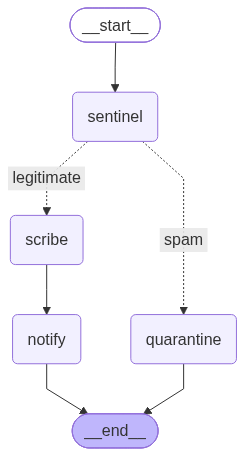

In [22]:
from IPython.display import Image, display

# Show the updated Multi-Agent Graph
display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [23]:
# Example legitimate email 
legitimate_email = {
    "sender": "recruiter@data-analytics-firm.com",
    "subject": "Machine Learning Engineer Role",
    "body": "Hi Waryam, I came across your GitHub repository detailing your exploratory data analysis on telecom customer churn. We have an opening on our data team and would love to discuss how your skills might be a good fit. Are you open to a call next week?"
}

# Example spam email 
spam_email = {
    "sender": "marketing@cheap-php-hosting.xyz",
    "subject": "70% OFF Web Hosting for your Backend Projects!!",
    "body": "Hello! Need a place to host your Academic Marksheet Generator? Get the cheapest cPanel hosting for all your PHP backend development projects. Click here to buy now before the offer expires!"
}

# Run the tests
print("--- TESTING LEGITIMATE EMAIL ---")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "triage_dossier": None,
    "email_draft": None,
    "saved_filepath": None,
    "messages": []
})

print("\n\n--- TESTING SPAM EMAIL ---")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "triage_dossier": None,
    "email_draft": None,
    "saved_filepath": None,
    "messages": []
})

--- TESTING LEGITIMATE EMAIL ---

[Sentinel] Scanning incoming email from: recruiter@data-analytics-firm.com
[Sentinel] Verdict: HAM
[Sentinel] Handing off dossier to Scribe:
  -> "The recruiter seeks to engage Waryam for a Machine Learning Engineer position, referencing his GitHub work to personalize the outreach. Prioritize a courteous reply that confirms interest, requests more details about the role, and proposes a convenient time for a call next week."

[Scribe] Receiving dossier from Sentinel. Crafting response...
[Scribe] Draft generated and successfully archived to: saved_drafts/draft_Machine_Learning_Engineer_Role_20260911_151416.txt

NOTIFICATION FOR WARYAM
From: recruiter@data-analytics-firm.com | Subject: Machine Learning Engineer Role
Archive Location: saved_drafts/draft_Machine_Learning_Engineer_Role_20260911_151416.txt
------------------------------------------------------------
Hi [Recruiter Name],

Thank you for reaching out and for your kind words about my GitHub work